In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_file_path = '/content/drive/My Drive/archive.zip'
extract_folder_path = '/content/BrainTumour_Dataset/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder_path)

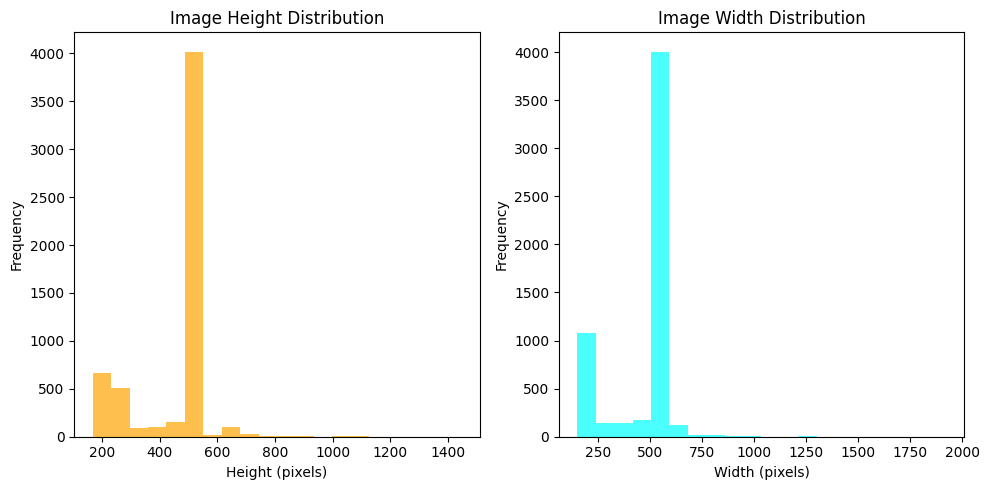

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# Update this path to where the dataset was unzipped
data_dir = '/content/BrainTumour_Dataset/Training/'
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
# Image Size Distribution
def plot_image_size_distribution(data_dir, categories):
    image_sizes = []
    for category in categories:
        category_path = os.path.join(data_dir, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image_sizes.append(img.shape)

    image_sizes = np.array(image_sizes)
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(image_sizes[:, 0], bins=20, color='orange', alpha=0.7)
    plt.title("Image Height Distribution")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(image_sizes[:, 1], bins=20, color='cyan', alpha=0.7)
    plt.title("Image Width Distribution")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_image_size_distribution(data_dir, categories)

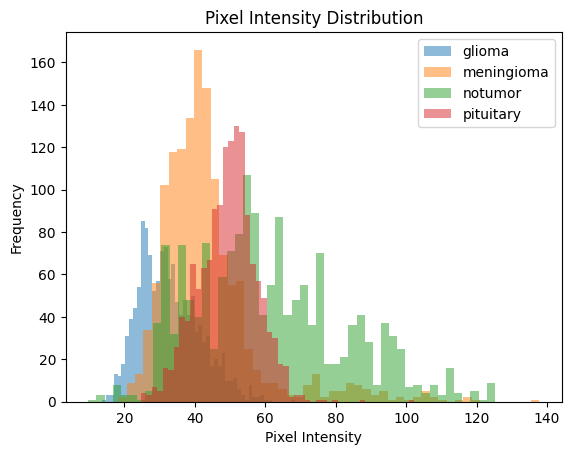

In [ ]:
import numpy as np
for category in categories:
    image_path = os.path.join(data_dir, category)
    images = [cv2.imread(os.path.join(image_path, img), 0) for img in os.listdir(image_path)]
    pixel_values = [np.mean(img) for img in images]
    plt.hist(pixel_values, bins=50, alpha=0.5, label=category)

plt.legend()
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

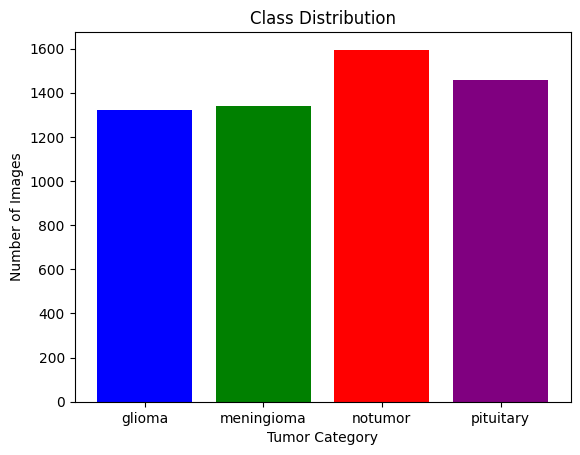

In [ ]:


# Class Distribution
def plot_class_distribution(data_dir, categories):
    class_counts = {}
    for category in categories:
        class_counts[category] = len(os.listdir(os.path.join(data_dir, category)))

    plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'green', 'red', 'purple'])
    plt.title("Class Distribution")
    plt.xlabel("Tumor Category")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(data_dir, categories)


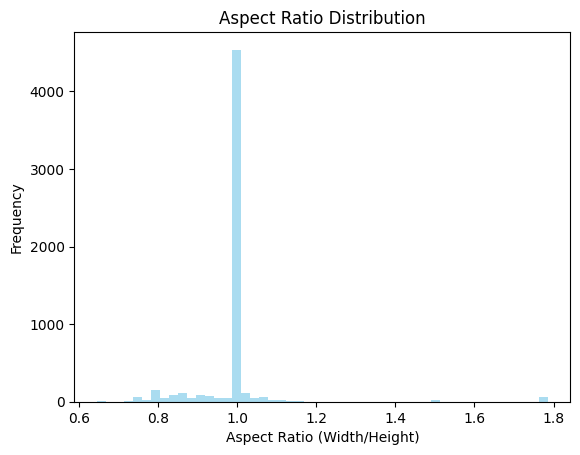

In [ ]:
def analyze_aspect_ratio(data_dir, categories):
    aspect_ratios = []
    for category in categories:
        category_path = os.path.join(data_dir, category)
        img_list = os.listdir(category_path)

        for img_name in img_list:
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                aspect_ratio = img.shape[1] / img.shape[0]
                aspect_ratios.append(aspect_ratio)

    plt.hist(aspect_ratios, bins=50, color='skyblue', alpha=0.7)
    plt.title("Aspect Ratio Distribution")
    plt.xlabel("Aspect Ratio (Width/Height)")
    plt.ylabel("Frequency")
    plt.show()

analyze_aspect_ratio(data_dir, categories)

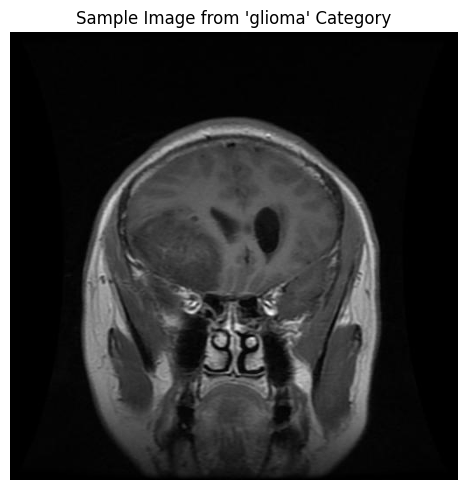

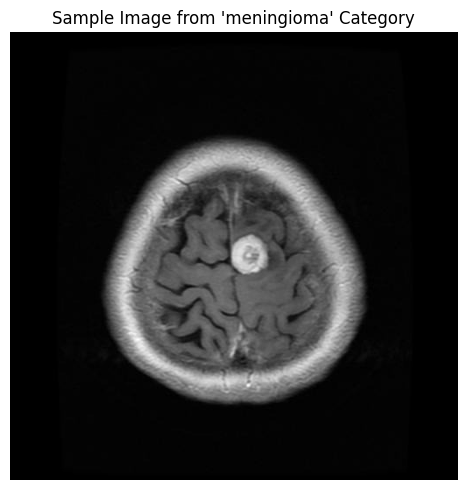

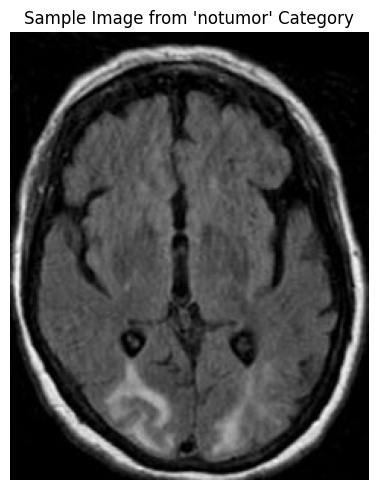

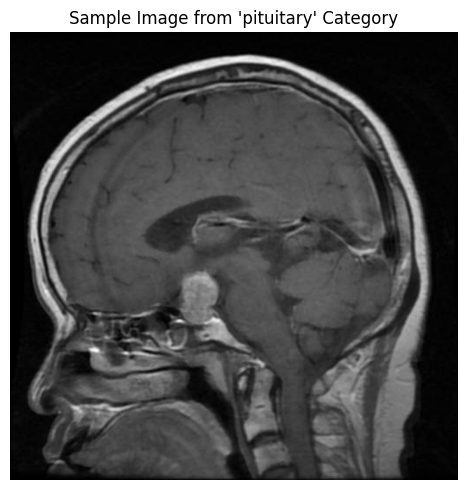

In [ ]:
def load_sample_image(data_dir, category):
    category_path = os.path.join(data_dir, category)
    sample_image_name = os.listdir(category_path)[0]  # Load the first image in the folder
    sample_image_path = os.path.join(category_path, sample_image_name)
    sample_image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
    return sample_image

# Visualize the image and its pixel intensity distribution
def visualize_image(image, category_name):
    # Plot the image
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Sample Image from '{category_name}' Category")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Load and visualize a sample image from one category
for category in categories:  # Choose a category to visualize
    sample_image = load_sample_image(data_dir, category)
    visualize_image(sample_image, category)

In [ ]:
import hashlib

def dhash(image, hash_size=8):
    resized = cv2.resize(image, (hash_size + 1, hash_size))
    diff = resized[:, 1:] > resized[:, :-1]
    return sum([2 ** i for (i, v) in enumerate(diff.flatten()) if v])

def remove_duplicates(data_dir):
    image_hashes = {}
    duplicates = []

    for category in os.listdir(data_dir):
        category_path = os.path.join(data_dir, category)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img_hash = dhash(img)

            if img_hash in image_hashes:
                print(f"Duplicate found: {img_name} is a duplicate of {image_hashes[img_hash]}")
                duplicates.append(img_path)
            else:
                image_hashes[img_hash] = img_name

    for duplicate in duplicates:
        os.remove(duplicate)
        print(f"Deleted duplicate image: {duplicate}")

remove_duplicates(data_dir)

Duplicate found: Tr-me_0366.jpg is a duplicate of Tr-me_0211.jpg
Duplicate found: Tr-me_0249.jpg is a duplicate of Tr-me_0251.jpg
Duplicate found: Tr-me_0616.jpg is a duplicate of Tr-me_0617.jpg
Duplicate found: Tr-me_0238.jpg is a duplicate of Tr-me_0227.jpg
Duplicate found: Tr-me_0175.jpg is a duplicate of Tr-me_0281.jpg
Duplicate found: Tr-me_0176.jpg is a duplicate of Tr-me_0211.jpg
Duplicate found: Tr-pi_0676.jpg is a duplicate of Tr-pi_0677.jpg
Duplicate found: Tr-pi_0518.jpg is a duplicate of Tr-pi_0517.jpg
Duplicate found: Tr-pi_0321.jpg is a duplicate of Tr-pi_0320.jpg
Duplicate found: Tr-pi_0160.jpg is a duplicate of Tr-pi_0159.jpg
Duplicate found: Tr-pi_0108.jpg is a duplicate of Tr-pi_0107.jpg
Duplicate found: Tr-pi_0169.jpg is a duplicate of Tr-pi_0170.jpg
Duplicate found: Tr-pi_0157.jpg is a duplicate of Tr-pi_0046.jpg
Duplicate found: Tr-pi_0526.jpg is a duplicate of Tr-pi_0529.jpg
Duplicate found: Tr-pi_0342.jpg is a duplicate of Tr-pi_0343.jpg
Duplicate found: Tr-pi_02

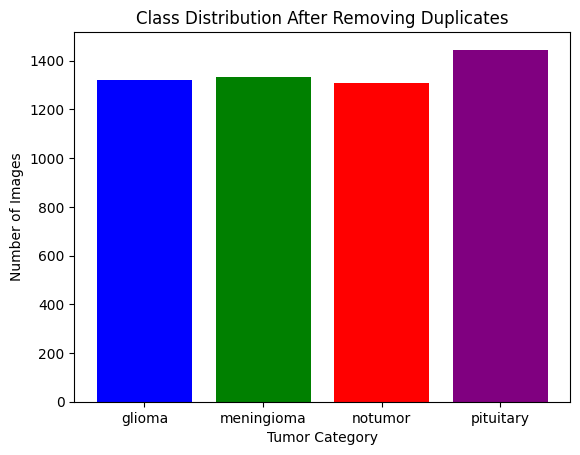

In [ ]:
def plot_class_distribution(data_dir, categories):
    class_counts = {}
    for category in categories:
        class_counts[category] = len(os.listdir(os.path.join(data_dir, category)))

    plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'green', 'red', 'purple'])
    plt.title("Class Distribution After Removing Duplicates")
    plt.xlabel("Tumor Category")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(data_dir, categories)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Define image size and other parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

# Paths
train_dir = '/content/BrainTumour_Dataset/Training/'
# If you have a separate validation directory, define it here. Otherwise, we'll split the training data.
# val_dir = '/content/BrainTumour_Dataset/Validation/'


In [ ]:
# ImageDataGenerator for training with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=30,           # Rotate images by 30 degrees
    width_shift_range=0.2,       # Horizontal shift
    height_shift_range=0.2,      # Vertical shift
    shear_range=0.2,             # Shear transformation
    zoom_range=0.2,              # Zoom in/out
    horizontal_flip=True,        # Randomly flip images
    fill_mode='nearest',         # Fill missing pixels
    validation_split=0.2          # Split 20% of data for validation
)

# ImageDataGenerator for validation (only rescaling)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',            # Set as training data
    shuffle=True,
    seed=42
)

# Create validation generator
validation_generator = validation_datagen.flow_from_directory(
    train_dir,                    # Same directory as training data
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',          # Set as validation data
    shuffle=True,
    seed=42
)


Found 4326 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.


In [ ]:
def build_basic_cnn(input_shape=(224, 224, 1), num_classes=4):
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # To prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Since the images are grayscale, set input_shape accordingly
input_shape = (IMG_SIZE, IMG_SIZE, 3)  # Grayscale
model = build_basic_cnn(input_shape=input_shape, num_classes=4)
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


135/135 ━━━━━━━━━━━━━━━━━━━━ 76s 469ms/step - accuracy: 0.4170 - loss: 4.9232 - val_accuracy: 0.2670 - val_loss: 12.5462
Epoch 2/20
  1/135 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.4375 - loss: 1.0698

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.4375 - loss: 1.0698 - val_accuracy: 0.2917 - val_loss: 8.3708
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 436ms/step - accuracy: 0.4512 - loss: 1.2557 - val_accuracy: 0.2661 - val_loss: 3.3189
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3438 - loss: 1.5099 - val_accuracy: 0.3750 - val_loss: 3.9018
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 79s 421ms/step - accuracy: 0.4948 - loss: 1.1920 - val_accuracy: 0.4081 - val_loss: 1.6423
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4688 - loss: 2.0614 - val_accuracy: 0.5000 - val_loss: 1.0924
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 59s 420ms/step - accuracy: 0.4796 - loss: 1.2089 - val_accuracy: 0.5256 - val_loss: 1.8335
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step - accuracy: 0.4688 - loss: 1.0340 - val_accuracy: 0.5000 - val_loss: 1.3280
Epoch 9/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 84s 435ms/step - accuracy: 0.5221 - loss: 1.0974 - val_accuracy

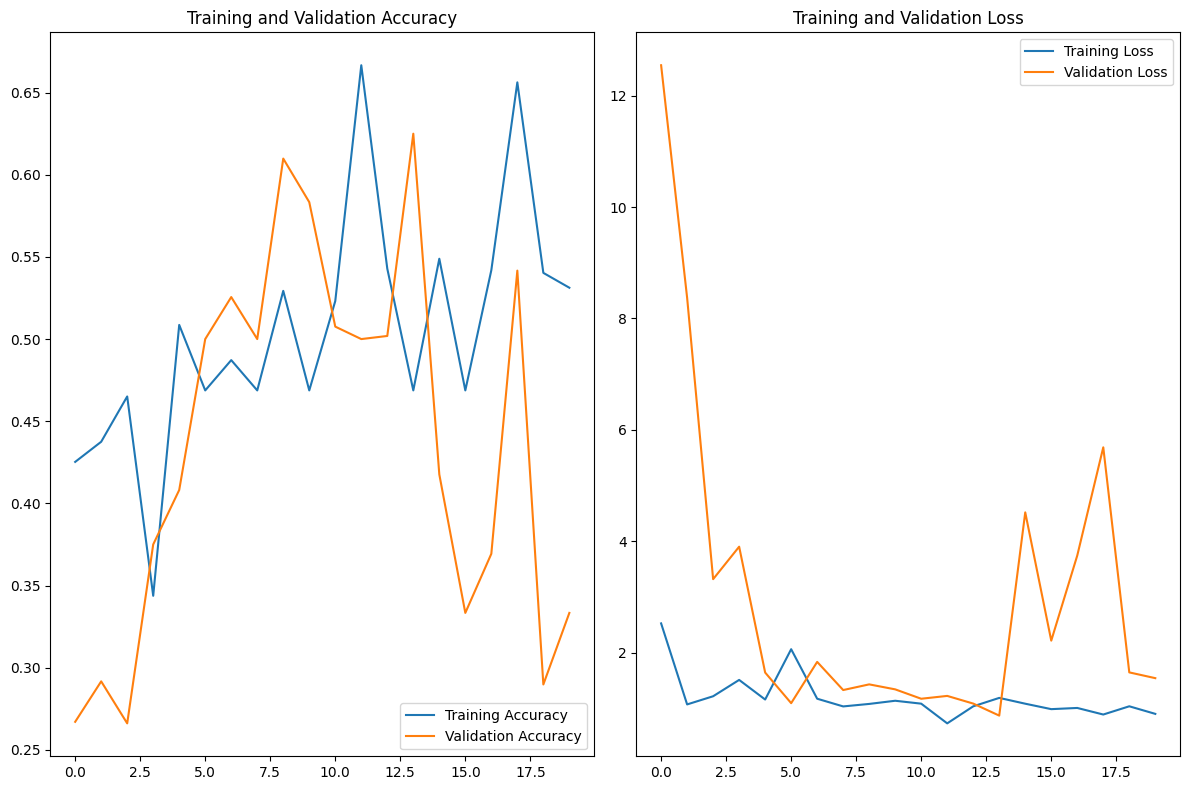

In [ ]:
# Train the model


# Plot the training and validation accuracy and loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_training_history(history)


In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, LeakyReLU, Flatten


class Discriminator(object):
    def __init__(self, input_shape):
        inputs = Input(input_shape)
        conv1 = Conv2D(64, (5, 5), padding='same')(inputs)
        conv1 = LeakyReLU(0.2)(conv1)
        pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
        conv2 = Conv2D(128, (5, 5), padding='same')(pool1)
        conv2 = LeakyReLU(0.2)(conv2)
        pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
        fc1 = Flatten()(pool2)
        fc1 = Dense(1)(fc1)
        outputs = Activation('sigmoid')(fc1)

        self.model = Model(inputs=[inputs], outputs=[outputs])

    def get_model(self):
        return self.model

In [ ]:
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, LeakyReLU, Reshape, Conv2DTranspose, Flatten, Embedding, multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Concatenate
from keras.callbacks import EarlyStopping


# Load and preprocess the dataset
def load_data(data_dir):
    images = []
    labels = []
    label_dict = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

    for label_name in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label_name)
        for img_file in os.listdir(label_dir):
            img_path = os.path.join(label_dir, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))  # Resizing to 64x64
            images.append(img)
            labels.append(label_dict[label_name])

    images = np.array(images).astype('float32') / 255.0  # Normalize
    labels = np.array(labels)
    return images, labels

# Load data
data_dir = '/content/BrainTumour_Dataset/Training/'
x_train, y_train = load_data(data_dir)

# Add a channel dimension for grayscale images
x_train = np.expand_dims(x_train, axis=-1)
num_classes = 4
input_dim = 100  # Noise dimension

# Build Conditional Generator Model
def build_generator(input_dim, num_classes):
    noise = Input(shape=(input_dim,))
    label = Input(shape=(1,), dtype='int32')

    label_embedding = Embedding(num_classes, input_dim, input_length=1)(label)
    label_embedding = Flatten()(label_embedding)

    model_input = multiply([noise, label_embedding])

    model = Sequential()
    model.add(Dense(256 * 8 * 8, input_dim=input_dim))
    model.add(Reshape((8, 8, 256)))
    model.add(Conv2DTranspose(128, (5,5), strides=(2,2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(64, (5,5), strides=(2,2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', activation='tanh'))

    img = model(model_input)

    return Model([noise, label], img)

# Build Conditional Discriminator Model
def build_discriminator(img_shape, num_classes):
    img = Input(shape=img_shape)
    label = Input(shape=(1,), dtype='int32')

    label_embedding = Embedding(num_classes, np.prod(img_shape))(label)
    label_embedding = Flatten()(label_embedding)
    label_embedding = Reshape(img_shape)(label_embedding)

    model_input = Concatenate(axis=-1)([img, label_embedding])

    model = Sequential()
    model.add(Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=(64,64,2)))
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    validity = model(model_input)

    return Model([img, label], validity)

# Define input dimensions and image shape
img_shape = (64, 64, 1)  # Image size for grayscale MRI images

# Build the Generator and Discriminator Models
generator = build_generator(input_dim, num_classes)
discriminator = build_discriminator(img_shape, num_classes)

# Compile the Discriminator with a lower learning rate and gradient clipping
opt = Adam(learning_rate=0.0001, beta_1=0.5)  # Lower learning rate
discriminator.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# The combined model
noise = Input(shape=(input_dim,))
label = Input(shape=(1,))
gen_img = generator([noise, label])
discriminator.trainable = False
validity = discriminator([gen_img, label])
combined = Model([noise, label], validity)
combined.compile(loss='binary_crossentropy', optimizer=opt)

# Training
def train(epochs, batch_size=32, save_interval=50):
    half_batch = batch_size // 2

    for epoch in range(epochs):

        # Train the Discriminator
        idx = np.random.randint(0, x_train.shape[0], half_batch)
        real_imgs = x_train[idx]
        labels_real = y_train[idx]

        noise = np.random.normal(0, 1, (half_batch, input_dim))
        labels_fake = np.random.randint(0, num_classes, half_batch)
        gen_imgs = generator.predict([noise, labels_fake])

        d_loss_real = discriminator.train_on_batch([real_imgs, labels_real], np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch([gen_imgs, labels_fake], np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train the Generator
        noise = np.random.normal(0, 1, (batch_size, input_dim))
        labels = np.random.randint(0, num_classes, batch_size)
        valid_y = np.array([1] * batch_size)
        g_loss = combined.train_on_batch([noise, labels], valid_y)

        # Print progress
        print(f"{epoch}/{epochs}, D loss: {d_loss[0]}, G loss: {g_loss}")

        # Save generated images at intervals
        if epoch % save_interval == 0:
            save_imgs(epoch)

# Save generated images
def save_imgs(epoch):
    noise = np.random.normal(0, 1, (25, input_dim))
    labels = np.random.randint(0, num_classes, 25)
    gen_imgs = generator.predict([noise, labels])

    # Rescale images 0 - 1
    gen_imgs = 0.5 * gen_imgs + 0.5

    for i in range(25):
        cv2.imwrite(f"images/gen_{epoch}_{i}.png", gen_imgs[i] * 255)

# Train the model
train(epochs=10000, batch_size=32, save_interval=200)




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
0/10000, D loss: 0.6945046186447144, G loss: [array(0.694088, dtype=float32), array(0.694088, dtype=float32), array(0.5, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/10000, D loss: 0.6942062377929688, G loss: [array(0.6940525, dtype=float32), array(0.6940525, dtype=float32), array(0.46875, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/10000, D loss: 0.6942776441574097, G loss: [array(0.6942135, dtype=float32), array(0.6942135, dtype=float32), array(0.39583334, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/10000, D loss: 0.6947821378707886, G loss: [array(0.6946863, dtype=float32), array(0.6946863, dtype=float32), array(0.359375, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
4/10000, D loss: 0.6948726177215576, G loss: [array(0.6948317, dtype=float32), array(0.6948317, dtype=float32), array(0.31875, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
5/10000, D loss: 0.69495

[0/50][0/25] Loss_D: 1.4219 Loss_G: 2.6022
[1/50][0/25] Loss_D: 0.0497 Loss_G: 10.5009
[2/50][0/25] Loss_D: 0.0061 Loss_G: 14.7929
[3/50][0/25] Loss_D: 0.0048 Loss_G: 12.0019
[4/50][0/25] Loss_D: 1.3310 Loss_G: 13.7713
[5/50][0/25] Loss_D: 0.3881 Loss_G: 4.2990
[6/50][0/25] Loss_D: 0.2356 Loss_G: 4.7532
[7/50][0/25] Loss_D: 0.2908 Loss_G: 4.5059
[8/50][0/25] Loss_D: 0.2611 Loss_G: 3.9826
[9/50][0/25] Loss_D: 0.0842 Loss_G: 5.5904
[10/50][0/25] Loss_D: 0.5067 Loss_G: 4.1968
[11/50][0/25] Loss_D: 0.3761 Loss_G: 4.5974
[12/50][0/25] Loss_D: 0.2047 Loss_G: 4.9670
[13/50][0/25] Loss_D: 0.0500 Loss_G: 8.2806
[14/50][0/25] Loss_D: 3.4590 Loss_G: 7.9551
[15/50][0/25] Loss_D: 0.4014 Loss_G: 7.3157
[16/50][0/25] Loss_D: 0.2217 Loss_G: 4.6508
[17/50][0/25] Loss_D: 0.2626 Loss_G: 4.9436
[18/50][0/25] Loss_D: 0.2265 Loss_G: 4.5066
[19/50][0/25] Loss_D: 0.1884 Loss_G: 5.0730
[20/50][0/25] Loss_D: 1.0384 Loss_G: 12.0239
[21/50][0/25] Loss_D: 0.8322 Loss_G: 10.0420
[22/50][0/25] Loss_D: 0.9819 Loss_G:

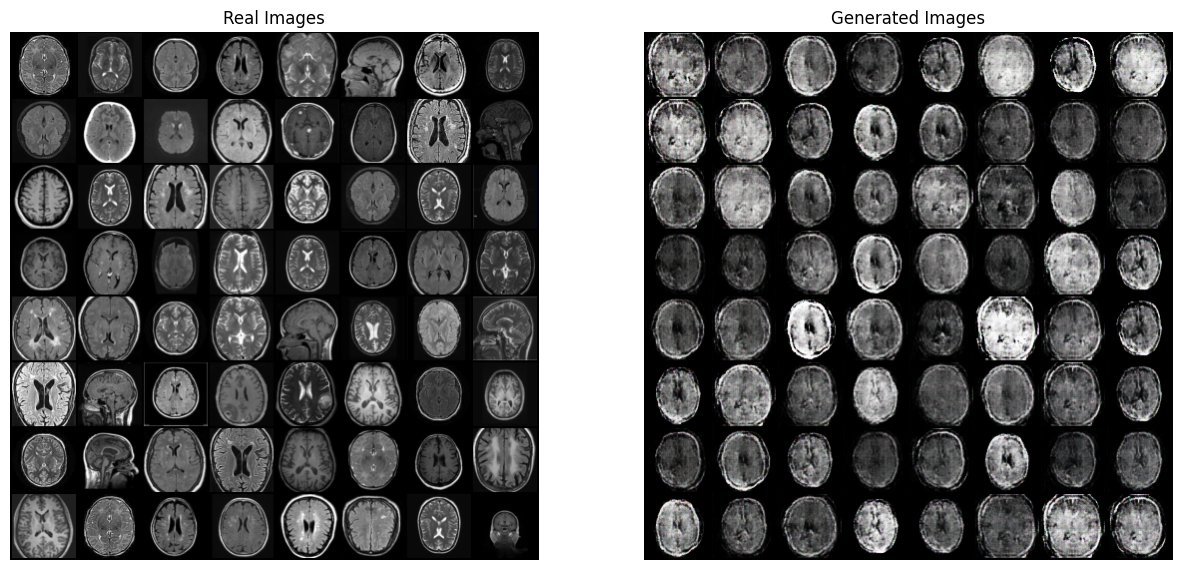

Generated Images:


AttributeError: module 'torchvision.utils' has no attribute 'print_image'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

# Set random seed for reproducibility
torch.manual_seed(42)

# Hyperparameters
latent_dim = 100
image_size = 64
batch_size = 64
num_epochs = 50
lr = 0.0002
beta1 = 0.5

# Set your dataset path here
dataset_path = "/content/BrainTumour_Dataset/Training/notumor"

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Custom Dataset class
class NoTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_list = [f for f in os.listdir(root_dir) if f.endswith('.jpg') or f.endswith('.png')]

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_list[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

# Function to load dataset
def load_dataset(data_path):
    dataset = NoTumorDataset(root_dir=data_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return dataloader

# Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

# Function to train the GAN
def train_gan(dataloader):
    netG = Generator().to(device)
    netD = Discriminator().to(device)

    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

    for epoch in range(num_epochs):
        for i, real_images in enumerate(dataloader):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Train Discriminator
            netD.zero_grad()
            label = torch.full((batch_size,), 1.0, device=device)
            output = netD(real_images)
            errD_real = criterion(output, label)
            errD_real.backward()

            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_images = netG(noise)
            label.fill_(0.0)
            output = netD(fake_images.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()

            errD = errD_real + errD_fake
            optimizerD.step()

            # Train Generator
            netG.zero_grad()
            label.fill_(1.0)
            output = netD(fake_images)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()

            if i % 100 == 0:
                print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

        # Save generated images
        with torch.no_grad():
            fake = netG(torch.randn(64, latent_dim, 1, 1, device=device)).detach().cpu()
            save_image(fake, f'fake_images_epoch_{epoch}.png', normalize=True)

    return netG, netD

# Function to compare real and generated images
def compare_images(real_images, fake_images):
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    plt.title("Real Images")
    plt.imshow(torchvision.utils.make_grid(real_images[:64], normalize=True).permute(1, 2, 0))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Generated Images")
    plt.imshow(torchvision.utils.make_grid(fake_images[:64], normalize=True).permute(1, 2, 0))
    plt.axis('off')

    plt.show()

# Main execution
if __name__ == "__main__":
    # Load the dataset
    dataloader = load_dataset(dataset_path)

    # Train the GAN
    netG, netD = train_gan(dataloader)

    # Generate and compare images
    real_batch = next(iter(dataloader))
    with torch.no_grad():
        fake_images = netG(torch.randn(64, latent_dim, 1, 1, device=device)).detach().cpu()
    compare_images(real_batch, fake_images)

    # Print generated images
    print("Generated Images:")
    torchvision.utils.print_image(fake_images[0])

[0/50][0/25] Loss_D: 1.4219 Loss_G: 2.6022
[1/50][0/25] Loss_D: 0.0345 Loss_G: 9.7145
[2/50][0/25] Loss_D: 0.0016 Loss_G: 17.9042
[3/50][0/25] Loss_D: 0.7880 Loss_G: 15.6659
[4/50][0/25] Loss_D: 0.3647 Loss_G: 5.8796
[5/50][0/25] Loss_D: 0.6134 Loss_G: 3.9497
[6/50][0/25] Loss_D: 0.2763 Loss_G: 4.3020
[7/50][0/25] Loss_D: 1.1602 Loss_G: 7.7253
[8/50][0/25] Loss_D: 0.2106 Loss_G: 5.6776
[9/50][0/25] Loss_D: 0.3712 Loss_G: 3.6555
[10/50][0/25] Loss_D: 0.3607 Loss_G: 4.9299
[11/50][0/25] Loss_D: 0.1826 Loss_G: 6.8146
[12/50][0/25] Loss_D: 0.2833 Loss_G: 7.3784
[13/50][0/25] Loss_D: 0.2485 Loss_G: 7.2898
[14/50][0/25] Loss_D: 0.1632 Loss_G: 5.2276
[15/50][0/25] Loss_D: 0.2152 Loss_G: 3.4624
[16/50][0/25] Loss_D: 0.6383 Loss_G: 8.9852
[17/50][0/25] Loss_D: 0.1721 Loss_G: 5.2794
[18/50][0/25] Loss_D: 0.2332 Loss_G: 5.3677
[19/50][0/25] Loss_D: 0.1786 Loss_G: 4.7716
[20/50][0/25] Loss_D: 0.0226 Loss_G: 3.0980
[21/50][0/25] Loss_D: 0.2550 Loss_G: 6.8186
[22/50][0/25] Loss_D: 0.2203 Loss_G: 4.7

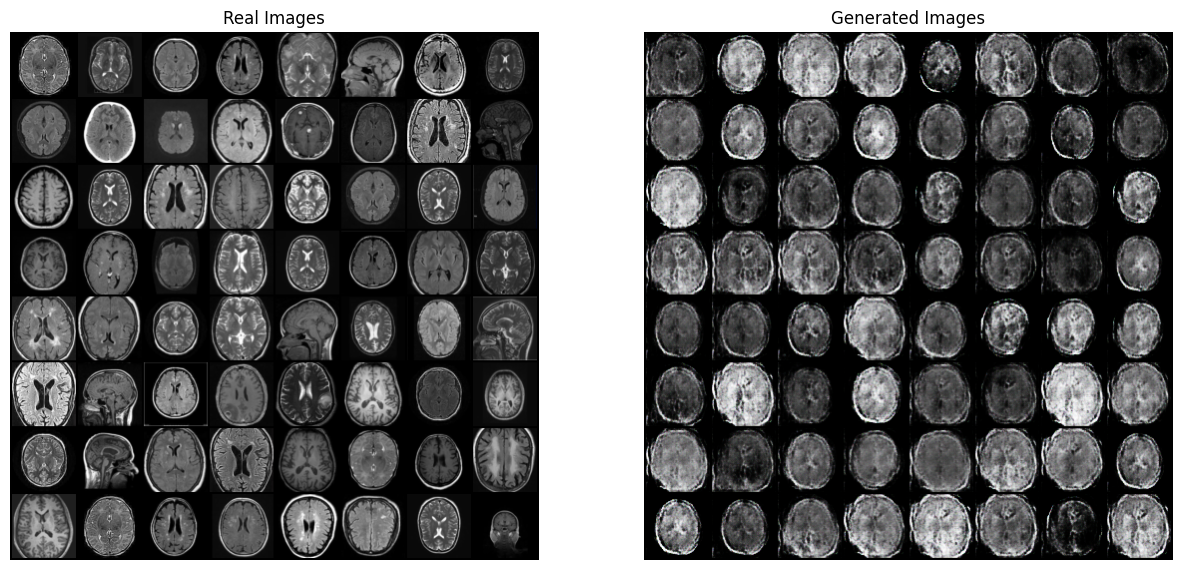

Generated Image:


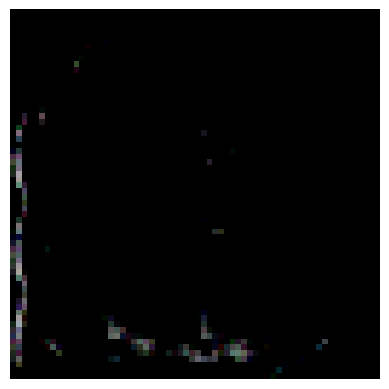

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

# Set random seed for reproducibility
torch.manual_seed(42)

# Hyperparameters
latent_dim = 100
image_size = 64
batch_size = 64
num_epochs = 50
lr = 0.0002
beta1 = 0.5

# Set your dataset path here
dataset_path = "/content/BrainTumour_Dataset/Training/notumor"

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Custom Dataset class
class NoTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_list = [f for f in os.listdir(root_dir) if f.endswith('.jpg') or f.endswith('.png')]

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_list[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

# Function to load dataset
def load_dataset(data_path):
    dataset = NoTumorDataset(root_dir=data_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return dataloader

# Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

# Function to train the GAN
def train_gan(dataloader):
    netG = Generator().to(device)
    netD = Discriminator().to(device)

    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

    for epoch in range(num_epochs):
        for i, real_images in enumerate(dataloader):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Train Discriminator
            netD.zero_grad()
            label = torch.full((batch_size,), 1.0, device=device)
            output = netD(real_images)
            errD_real = criterion(output, label)
            errD_real.backward()

            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_images = netG(noise)
            label.fill_(0.0)
            output = netD(fake_images.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()

            errD = errD_real + errD_fake
            optimizerD.step()

            # Train Generator
            netG.zero_grad()
            label.fill_(1.0)
            output = netD(fake_images)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()

            if i % 100 == 0:
                print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

        # Save generated images
        with torch.no_grad():
            fake = netG(torch.randn(64, latent_dim, 1, 1, device=device)).detach().cpu()
            save_image(fake, f'fake_images_epoch_{epoch}.png', normalize=True)

    return netG, netD

# Function to compare real and generated images
def compare_images(real_images, fake_images):
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    plt.title("Real Images")
    plt.imshow(make_grid(real_images[:64], normalize=True).permute(1, 2, 0))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Generated Images")
    plt.imshow(make_grid(fake_images[:64], normalize=True).permute(1, 2, 0))
    plt.axis('off')

    plt.show()

# Main execution
if __name__ == "__main__":
    # Load the dataset
    dataloader = load_dataset(dataset_path)

    # Train the GAN
    netG, netD = train_gan(dataloader)

    # Generate and compare images
    real_batch = next(iter(dataloader))
    with torch.no_grad():
        fake_images = netG(torch.randn(64, latent_dim, 1, 1, device=device)).detach().cpu()
    compare_images(real_batch, fake_images)

    # Display a single generated image
    print("Generated Image:")
    plt.imshow(fake_images[0].permute(1, 2, 0))
    plt.axis('off')
    plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

def load_and_preprocess_images(data_dir, target_size=(256, 256)):
    images = []
    for img_name in os.listdir(data_dir):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(data_dir, img_name)
            img = load_img(img_path, color_mode='grayscale', target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)

    return np.array(images)

def normalize_images(images):
    # Normalize to [-1, 1] range
    return (images / 127.5) - 1

def create_datasets(images, batch_size=32, validation_split=0.2):
    # Split the data into training and validation sets
    train_images, val_images = train_test_split(images, test_size=validation_split, random_state=42)

    # Create TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(1000).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices(val_images).batch(batch_size)

    return train_dataset, val_dataset

def preprocess_mri_dataset(data_dir, target_size=(256, 256), batch_size=32, validation_split=0.2):
    # Load and preprocess images
    images = load_and_preprocess_images(data_dir, target_size)

    # Normalize images
    normalized_images = normalize_images(images)

    # Create datasets
    train_dataset, val_dataset = create_datasets(normalized_images, batch_size, validation_split)

    return train_dataset, val_dataset

# Example usage
if __name__ == "__main__":
    data_dir = "/content/BrainTumour_Dataset/Training/notumor"
    train_dataset, val_dataset = preprocess_mri_dataset(data_dir)

    print("Training dataset:", train_dataset)
    print("Validation dataset:", val_dataset)

Training dataset: <_BatchDataset element_spec=TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)>
Validation dataset: <_BatchDataset element_spec=TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)>


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt

def build_generator(latent_dim, output_shape):
    model = models.Sequential([
        layers.Dense(16 * 16 * 256, input_dim=latent_dim),
        layers.Reshape((16, 16, 256)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(16, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(1, kernel_size=4, strides=1, padding='same', activation='tanh')
    ])
    return model

def build_discriminator(input_shape):
    model = models.Sequential([
        layers.Conv2D(16, kernel_size=4, strides=2, padding='same', input_shape=input_shape),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(256, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

class GAN(models.Model):
    def __init__(self, latent_dim, input_shape):
        super(GAN, self).__init__()
        self.latent_dim = latent_dim
        self.generator = build_generator(latent_dim, input_shape)
        self.discriminator = build_discriminator(input_shape)

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(GAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(latent_vectors, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)
            disc_loss = self.loss_fn(tf.ones_like(real_output), real_output) + \
                        self.loss_fn(tf.zeros_like(fake_output), fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return {"d_loss": disc_loss, "g_loss": gen_loss}

def train_gan(gan, dataset, epochs, batch_size):
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        for batch in dataset:
            gan.train_step(batch)

        # Generate and save sample images
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(gan, epoch + 1)

def generate_and_save_images(gan, epoch):
    test_input = tf.random.normal([16, gan.latent_dim])
    generated_images = gan.generator(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.savefig(f'generated_images_epoch_{epoch}.png')
    plt.close()

# Hyperparameters
latent_dim = 100
input_shape = (256, 256, 1)
batch_size = 32
epochs = 100
learning_rate = 0.0002
beta_1 = 0.5

# Create and compile the GAN
gan = GAN(latent_dim, input_shape)
gan.compile(
    g_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    d_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=False)
)

# Assuming you have already preprocessed your dataset
# train_dataset = ...

# Train the GAN
train_gan(gan, train_dataset, epochs, batch_size)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_generator_input_shape(generator):
    # Get the input shape of the generator
    if hasattr(generator, 'input_shape'):
        input_shape = generator.input_shape
    else:
        # If the model doesn't have an input_shape attribute, get it from the first layer
        input_shape = generator.layers[0].input_shape

    if isinstance(input_shape, list):
        input_shape = input_shape[0]

    # Remove the batch size dimension if it's None
    if input_shape[0] is None:
        input_shape = input_shape[1:]

    return input_shape

def generate_images_in_batches(generator, num_images=1000, batch_size=32):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)  # Calculate total number of elements
    num_batches = (num_images + batch_size - 1) // batch_size
    generated_images = []
    for _ in range(num_batches):
        batch_size = min(batch_size, num_images - len(generated_images))
        latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        # Reshape latent vectors to match the input shape expected by the generator
        reshaped_vectors = tf.reshape(latent_vectors, (batch_size,) + input_shape)
        batch_images = generator(reshaped_vectors, training=False)
        generated_images.append(batch_images)
        if len(generated_images) * batch_size >= num_images:
            break
    return tf.concat(generated_images, axis=0)[:num_images]

def visualize_generated_images(generated_images, num_images=25):
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('generated_images.png')
    plt.close()

def interpolate_latent_space(generator, num_steps=10):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)
    start_vector = tf.random.normal(shape=(1, latent_dim))
    end_vector = tf.random.normal(shape=(1, latent_dim))

    alphas = np.linspace(0, 1, num_steps)
    interpolated_vectors = tf.convert_to_tensor(
        [(1 - alpha) * start_vector + alpha * end_vector for alpha in alphas]
    )
    # Reshape interpolated vectors
    interpolated_vectors = tf.reshape(interpolated_vectors, (num_steps,) + input_shape)

    interpolated_images = generator(interpolated_vectors, training=False)

    fig, axes = plt.subplots(1, num_steps, figsize=(20, 4))
    for i, ax in enumerate(axes):
        ax.imshow(interpolated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('latent_space_interpolation.png')
    plt.close()

def visualize_latent_space(generator, num_samples=1000):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)
    latent_vectors = tf.random.normal(shape=(num_samples, latent_dim))
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.5)
    plt.title('t-SNE visualization of latent space')
    plt.savefig('latent_space_tsne.png')
    plt.close()

def total_variation(images):
    pixel_dif1 = images[:, 1:, :, :] - images[:, :-1, :, :]
    pixel_dif2 = images[:, :, 1:, :] - images[:, :, :-1, :]
    total_var = tf.reduce_sum(tf.abs(pixel_dif1)) + tf.reduce_sum(tf.abs(pixel_dif2))
    return total_var / tf.cast(tf.reduce_prod(tf.shape(images)), tf.float32)

def calculate_fid(real_images, generated_images):
    # This is a simplified FID calculation and should be replaced with a proper implementation
    real_mean = tf.reduce_mean(real_images, axis=0)
    generated_mean = tf.reduce_mean(generated_images, axis=0)
    return tf.reduce_mean(tf.square(real_mean - generated_mean))

def post_training_analysis(gan, train_dataset, num_images=1000, batch_size=32):
    # Generate images in batches
    generated_images = generate_images_in_batches(gan.generator, num_images, batch_size)

    # Visualize generated images
    visualize_generated_images(generated_images[:25])

    # Interpolate in latent space
    interpolate_latent_space(gan.generator)

    # Visualize latent space
    visualize_latent_space(gan.generator, num_samples=1000)

    # Evaluate image quality
    tv_score = total_variation(generated_images[:100])  # Calculate TV score for first 100 images
    print(f"Total Variation score: {tv_score}")

    # Calculate FID score
    real_images = next(iter(train_dataset))  # Get a batch of real images from the training dataset
    fid_score = calculate_fid(real_images, generated_images[:len(real_images)])
    print(f"FID score (simplified): {fid_score}")

# Assuming you have your trained GAN model and train_dataset
# gan = ...  # Your trained GAN model
# train_dataset = ...  # Your training dataset

# Run post-training analysis
post_training_analysis(gan, train_dataset, num_images=1000, batch_size=32)

Total Variation score: 0.16518966853618622
FID score (simplified): 0.01530415378510952


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import gaussian_filter

def generate_and_visualize_images(generator, num_images=16):
    latent_dim = generator.input_shape[1]
    noise = tf.random.normal([num_images, latent_dim])
    generated_images = generator(noise, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('generated_brain_mri.png')
    plt.close()
    return generated_images
  generated_images

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 21)